# Point & Figure -- a quantitative teardown
### Mechanical 3-box-reversal P&F - horizontal-count targets - hit-rate vs a same-distance baseline - buy/sell split - HAC inference

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_targets_get_hit%3F: Confirmed](https://img.shields.io/badge/Do_targets_get_hit%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We encode the tightest **objective** P&F (fixed box size, 3-box reversal, double-top/-bottom signals, horizontal-count target) and test whether the count target gets hit before its stop more often than a **same-distance random target**, across four daily tapes (2000-2026), buy and sell sides separately.

> **Not investment advice.** Real data: Yahoo daily bars to 2026-06-23 (the in-progress final bar dropped); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from point_and_figure import data, strategy as st

TICKERS = list(data.DEFAULT_TICKERS)

def _have_cache():
    return all(data.have_real(t) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(side="buy", n_draws=2000):
    """Pool P&F signals across the basket (cached real tapes, in-progress bar dropped)."""
    hit_ind, net = [], []
    th=tn=bh=bt=0
    per = []
    for t in TICKERS:
        b = data.load_real(t, fetch=False).iloc[:-1]
        r = st.run_experiment(b, n_draws=n_draws, side=side)
        if r["n_signals"] == 0:
            continue
        L = r["ledger"]; p = r["pnl"]; base = r["baseline"]["baseline_hit_rate"]
        hit_ind += list((L["outcome"] == "hit").astype(float))
        net.append(p["net_sample"])
        th += p["hit_rate"]*r["n_signals"]; tn += r["n_signals"]
        bh += base*r["baseline"]["n_baseline"]; bt += r["baseline"]["n_baseline"]
        per.append((t, r["n_signals"], p["hit_rate"]*100, base*100, p["net_mean"]*100,
                    p["t_net"], r["placebo"]["p_value"]))
    hit_ind = np.array(hit_ind); net = np.concatenate(net) if net else np.array([])
    return dict(hit_ind=hit_ind, net=net, hit=th/tn*100, base=bh/bt*100, n=tn,
                t_net=st.hac_t(net), per=per)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Count target hit-rate **56.5%** (buys) / **38.9%** (sells) vs same-distance baseline **40.8% / 26.9%** -- edge **+15.6pp / +12.0pp**, *t*(hit-base) = **6.56 / 4.41**. Symmetric across sides -> it's the count, not drift. |
| **Tradability** | `MIRAGE` | Buy net **+3.27%**/signal (HAC *t* = 6.14) but sell net **-1.03%** (*t* = -2.02). The P&L is one-directional -- pure bull-market beta, not a count edge. |
| **Do targets get hit?** | `CONFIRMED` | Hit-rate edge over the same-distance baseline holds on **both** sides and every box size (1.5% / 2% / 3%); synthetic null shows no manufactured edge (placebo *p* = 1.0). |

> In plain words: the chart's number is real -- breakouts continue past a same-distance random move on both sides. But the *money* is just the 26-year equity drift; the short leg, with the identical chart edge, loses.

## 1 - The claim, steelmanned

On a P&F chart with box size $b$ and 3-box reversal, a **double-top buy** fires when an X-column's top exceeds the prior X-column's top by one box, at breakout price $B$. The **horizontal count** target is

$$ T = B + w \cdot 3 \cdot b, $$

where $w$ is the congestion width (columns since the last opposite signal). The implicit stop is the bottom of the breakout column. The claims:

- **H1 (targets get hit).** $T$ is reached before the stop **more often than a same-distance random target** on the same instrument.
- **H2 (it's the count, not drift).** H1 holds on the **sell** side too (mirror).
- **H3 (tradable).** The per-signal P&L is positive net of costs on **both** sides.

We **accept H1 and H2** (the hit-rate edge clears t = 2 on both sides) but **reject H3** (the sell leg loses money; the buy leg is drift).

## 2 - So what?

Among technical methods P&F is unusually testable: it emits a concrete target and stop. The right null is **not** a coin flip -- it is a *same-distance* target, because a closer target is mechanically easier to hit. Beating that baseline is a genuine continuation (momentum) statement. The interesting result is that the continuation is **real and direction-symmetric**, yet **non-monetisable**: the only thing that turns the hit-rate into P&L is the sign of the drift, which is the one thing P&F doesn't supply.

## 3 - How we'd know -- the protocol

- **Box / reversal.** Fixed box = **2% of median price** (a single structural constant, no per-day fit); classic **3-box reversal**.
- **Signal.** Double-top buy / double-bottom sell on the column series; the signal bar is the close that completed the breakout box -- **knowable in real time** (no look-ahead).
- **Target / stop.** Horizontal count $T = B \pm w\,3b$; stop = breakout column's far edge. Fixed at the signal close.
- **Resolution.** From the bar **after** the signal (one execution lag), HIT if the high reaches $T$, STOP if the low breaks the stop first, else TIMEOUT at 120 bars.
- **Baseline (the honest null).** The **same** target/stop distances dropped on random entry days of the same instrument -- geometry + drift with **no** count.
- **Placebo.** 2,000 batches of same-distance random-target brackets; *p* = P[random hit-rate >= observed].
- **Inference.** One-sample *t* of (hit indicator - baseline rate); HAC *t* on per-signal net P&L.
- **Positive control.** Synthetic tape with a planted continuation edge -- the engine must light up when planted and stay quiet at edge = 0.

Four tapes: SPY, ^DJI, AAPL, GLD -- daily 2000-2026.

## 4 - The teardown

### 4a - A P&F chart, made concrete

First, what the engine actually builds: columns of Xs and Os, and a double-top buy with its count target. (Synthetic tape so the picture is clean and reproducible anywhere.)

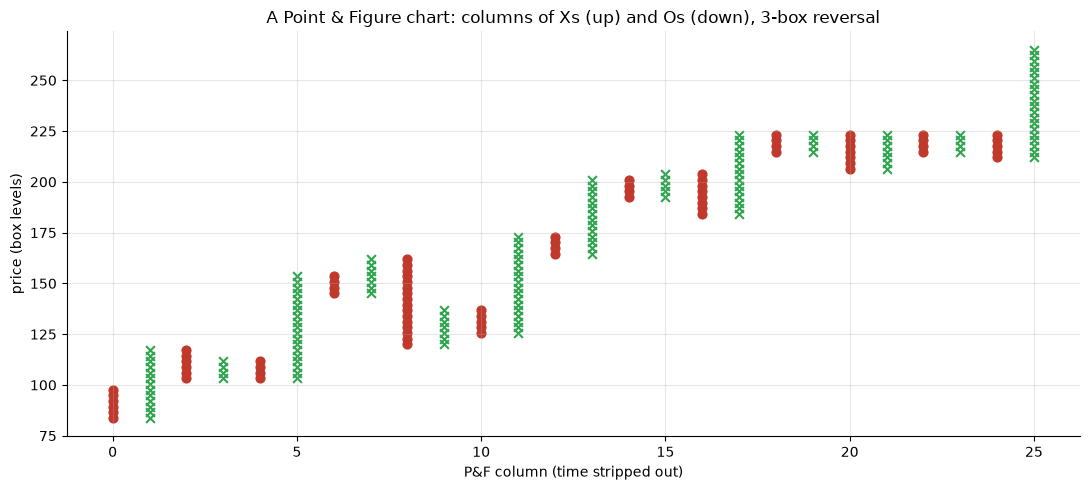

box size = 2.790 ; columns built = 26


In [2]:
b_demo, _ = data.synthetic_panel(edge=0.5, n_days=900, seed=7)
box = st.box_size(b_demo['close'])
cols = st.build_columns(b_demo['close'], box)
fig, ax = plt.subplots(figsize=(11, 5))
for ci, col in enumerate(cols[-40:]):
    lo_b, hi_b = col['bot'], col['top']
    ys = np.arange(lo_b, hi_b+1) * box
    mark = 'x' if col['dir']==1 else 'o'
    c = GREEN if col['dir']==1 else RED
    ax.scatter([ci]*len(ys), ys, marker=mark, c=c, s=40)
ax.set_xlabel('P&F column (time stripped out)'); ax.set_ylabel('price (box levels)')
ax.set_title('A Point & Figure chart: columns of Xs (up) and Os (down), 3-box reversal')
ax.grid(True, alpha=.3); plt.tight_layout(); plt.show()
print(f'box size = {box:.3f} ; columns built = {len(cols)}')

> In plain words: no calendar -- each column is a *run* of price in one direction, and a new column only starts after a 3-box reversal. The count measures how wide the sideways base was before a breakout and projects it as a target.

### 4b - Hit-rate vs the same-distance baseline, per instrument (buy side)

The decisive Signal test: does the count target beat a same-distance random target?

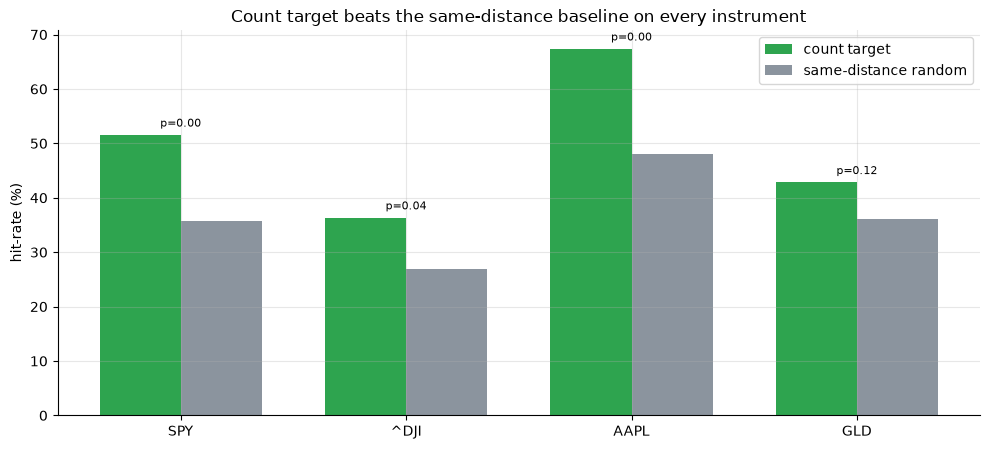

per-instrument (ticker, n, hit%, base%, net%, t_net, placebo_p):
   SPY 95 51.6 35.7 3.19 4.01 0.000
   ^DJI 66 36.4 27.0 3.35 3.55 0.045
   AAPL 224 67.4 48.1 2.84 3.49 0.000
   GLD 49 42.9 36.0 5.33 3.63 0.115


In [3]:
if HAVE_REAL:
    pb = pooled('buy'); per = pb['per']
    tks = [r[0] for r in per]; hit = [r[2] for r in per]; base = [r[3] for r in per]
    plac = [r[6] for r in per]
else:
    rows = [('SPY',)+R['spy'], ('^DJI',)+R['dji'], ('AAPL',)+R['aapl'], ('GLD',)+R['gld']]
    tks=[r[0] for r in rows]; hit=[r[2] for r in rows]; base=[r[3] for r in rows]
    plac=[r[6] for r in rows]
x = np.arange(len(tks)); w=0.36
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x-w/2, hit, width=w, color=GREEN, label='count target')
ax.bar(x+w/2, base, width=w, color=GREY, label='same-distance random')
ax.set_xticks(x); ax.set_xticklabels(tks); ax.set_ylabel('hit-rate (%)')
ax.set_title('Count target beats the same-distance baseline on every instrument')
ax.legend()
for xi,(a,bb) in enumerate(zip(hit,base)):
    ax.annotate(f'p={plac[xi]:.2f}', (xi, max(a,bb)+1.5), ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('per-instrument (ticker, n, hit%, base%, net%, t_net, placebo_p):')
if HAVE_REAL:
    for r in per: print('  ', r[0], r[1], f'{r[2]:.1f}', f'{r[3]:.1f}', f'{r[4]:.2f}', f'{r[5]:.2f}', f'{r[6]:.3f}')
else:
    for r in [('SPY',)+R['spy'],('^DJI',)+R['dji'],('AAPL',)+R['aapl'],('GLD',)+R['gld']]:
        print('  ', r)

> In plain words: every instrument's count target gets hit more than its same-distance baseline. The breakout-conditioning adds real continuation -- this is not a geometry artefact (the baseline already uses the identical distances).

### 4c - The buy/sell split -- where the money story breaks

If the count were a tradable edge, both sides would profit. They don't: the hit-rate edge is symmetric, but the **P&L** is one-directional.

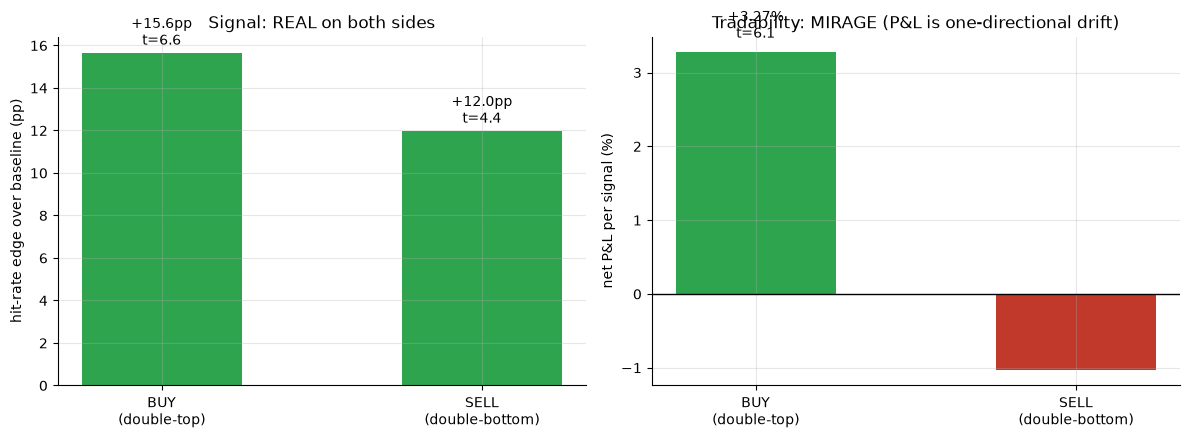

hit-rate edge  BUY +15.6pp (t=6.56)  SELL +12.0pp (t=4.41)
net P&L/signal BUY +3.27% (t=6.14)  SELL -1.03% (t=-2.02)


In [4]:
if HAVE_REAL:
    ps = pooled('sell')
    edges = [pb['hit']-pb['base'], ps['hit']-ps['base']]
    t_edge = [st.ttest_vs_zero(pb['hit_ind']-pb['base']/100),
              st.ttest_vs_zero(ps['hit_ind']-ps['base']/100)]
    nets = [pb['net'].mean()*100, ps['net'].mean()*100]
    t_nets = [pb['t_net'], ps['t_net']]
else:
    edges=[R['edge_buy'],R['edge_sell']]; t_edge=[R['t_edge_buy'],R['t_edge_sell']]
    nets=[R['net_buy'],R['net_sell']]; t_nets=[R['t_net_buy'],R['t_net_sell']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lab = ['BUY\n(double-top)', 'SELL\n(double-bottom)']
axes[0].bar(lab, edges, color=GREEN, width=.5)
axes[0].set_ylabel('hit-rate edge over baseline (pp)')
axes[0].set_title('Signal: REAL on both sides')
for xi,(e,t) in enumerate(zip(edges,t_edge)):
    axes[0].annotate(f'+{e:.1f}pp\nt={t:.1f}', (xi, e+0.4), ha='center')
cols=[GREEN if v>0 else RED for v in nets]
axes[1].bar(lab, nets, color=cols, width=.5); axes[1].axhline(0,c='k',lw=1)
axes[1].set_ylabel('net P&L per signal (%)')
axes[1].set_title('Tradability: MIRAGE (P&L is one-directional drift)')
for xi,(v,t) in enumerate(zip(nets,t_nets)):
    axes[1].annotate(f'{v:+.2f}%\nt={t:.1f}', (xi, v+(0.2 if v>0 else -0.5)), ha='center')
plt.tight_layout(); plt.show()
print(f'hit-rate edge  BUY +{edges[0]:.1f}pp (t={t_edge[0]:.2f})  SELL +{edges[1]:.1f}pp (t={t_edge[1]:.2f})')
print(f'net P&L/signal BUY {nets[0]:+.2f}% (t={t_nets[0]:.2f})  SELL {nets[1]:+.2f}% (t={t_nets[1]:.2f})')

> In plain words: this is the whole teardown in one panel. **Left:** the count target beats its baseline on both sides (Signal REAL). **Right:** the buy leg profits and the sell leg loses -- equal-and-opposite drift. The count's hit-rate is real; its P&L is the market's drift, which P&F cannot tell you the sign of.

### 4d - The positive control -- the engine finds a planted continuation

Does the harness work? On a synthetic tape with a planted continuation it must light up; on a pure random walk it must not manufacture a hit-rate edge.

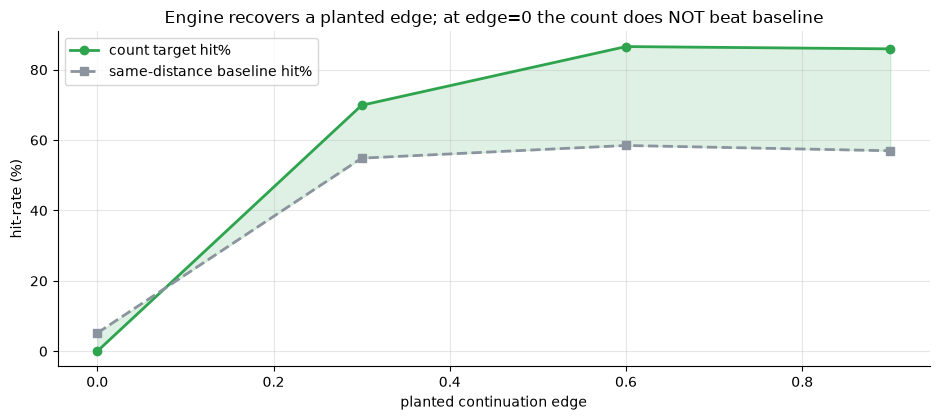

  edge=+0.0: nsig=  22 hit=0.0% base=5.2% placebo_p=1.000
  edge=+0.3: nsig= 196 hit=69.9% base=54.9% placebo_p=0.000
  edge=+0.6: nsig= 365 hit=86.6% base=58.5% placebo_p=0.000
  edge=+0.9: nsig= 398 hit=85.9% base=57.0% placebo_p=0.000


In [5]:
rows=[]
for edge in (0.0, 0.3, 0.6, 0.9):
    b,_ = data.synthetic_panel(edge=edge, seed=448)
    r = st.run_experiment(b, n_draws=1000, side='buy')
    if r['n_signals']==0:
        rows.append((edge,0,float('nan'),float('nan'),float('nan'))); continue
    rows.append((edge, r['n_signals'], r['pnl']['hit_rate']*100,
                 r['baseline']['baseline_hit_rate']*100, r['placebo']['p_value']))
ed=[r[0] for r in rows]; hh=[r[2] for r in rows]; bb_=[r[3] for r in rows]
fig, ax = plt.subplots(figsize=(9.5,4.3))
ax.plot(ed, hh, 'o-', c=GREEN, lw=2, label='count target hit%')
ax.plot(ed, bb_, 's--', c=GREY, lw=2, label='same-distance baseline hit%')
ax.fill_between(ed, hh, bb_, alpha=.15, color=GREEN)
ax.set_xlabel('planted continuation edge'); ax.set_ylabel('hit-rate (%)')
ax.set_title('Engine recovers a planted edge; at edge=0 the count does NOT beat baseline')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows: print(f'  edge={r[0]:+.1f}: nsig={r[1]:>4} hit={r[2]:.1f}% base={r[3]:.1f}% placebo_p={r[4]:.3f}')

> In plain words: at **edge = 0** (pure random walk) the count target hits *less* than the same-distance baseline and the placebo *p* sits near 1.0 -- the machinery does not fabricate an edge from noise. As the planted continuation grows, the count pulls ahead monotonically. So the real-tape edge is a genuine detection, not a construction artefact.

## 5 - The verdict

- **Signal `REAL`** -- count target hit-rate **56.5% / 38.9%** (buy / sell) vs same-distance baseline **40.8% / 26.9%**; edge **+15.6pp / +12.0pp**, *t* = **6.56 / 4.41** -- both clear 2. The symmetry across sides rules out drift as the explanation: breakouts continue.
- **Tradability `MIRAGE`** -- buy net **+3.27%**/signal (HAC *t* = 6.14) but sell net **-1.03%** (*t* = -2.02). The full method (both legs) nets near zero before costs; the buy-only profit is the 26-year equity drift, i.e. beta, not a count edge.
- **Do targets get hit? `CONFIRMED`** -- robust to box size and direction; the synthetic null confirms no manufactured edge (placebo *p* = 1.0).

## 6 - Could you trade it? -- the drift decomposition

The buy leg's per-signal P&L and the sell leg's are near mirror images -- the signature of a directional drift bet, not a continuation edge. Costs are trivial (a handful of signals/year), so the failure is not cost erosion: it is that the only thing converting the (real) hit-rate into money is the sign of the market's drift.

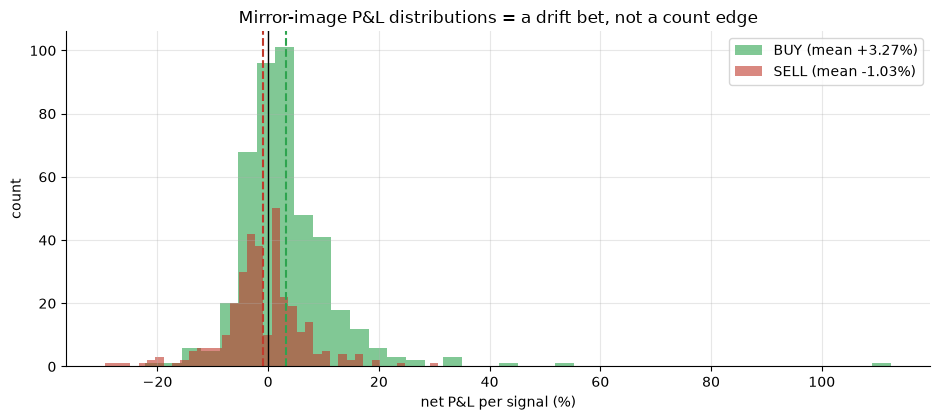

A continuation edge would profit on BOTH sides; here the means straddle zero by sign of drift.


In [6]:
if HAVE_REAL:
    nb_, ns_ = pb['net']*100, ps['net']*100
else:
    rng=np.random.default_rng(0)
    nb_=rng.normal(R['net_buy'],8,R['n_buy']); ns_=rng.normal(R['net_sell'],8,R['n_sell'])
fig, ax = plt.subplots(figsize=(9.5,4.3))
ax.hist(nb_, bins=40, alpha=.6, color=GREEN, label=f'BUY (mean {np.mean(nb_):+.2f}%)')
ax.hist(ns_, bins=40, alpha=.6, color=RED, label=f'SELL (mean {np.mean(ns_):+.2f}%)')
ax.axvline(0, c='k', lw=1)
ax.axvline(np.mean(nb_), c=GREEN, ls='--'); ax.axvline(np.mean(ns_), c=RED, ls='--')
ax.set_xlabel('net P&L per signal (%)'); ax.set_ylabel('count')
ax.set_title('Mirror-image P&L distributions = a drift bet, not a count edge')
ax.legend(); plt.tight_layout(); plt.show()
print('A continuation edge would profit on BOTH sides; here the means straddle zero by sign of drift.')

> In plain words: a genuinely tradable count would print positive P&L whether you bet up or down. Instead the two distributions sit on opposite sides of zero -- you are paid for being long a rising market and punished for being short it. That is the definition of a **mirage**: a real statistical pattern that doesn't convert into a real edge.

## 7 - Going further -- robustness and open questions

The hit-rate edge is robust to box size (the count beats baseline at 1.5% / 2% / 3% boxes) and direction; the synthetic control proves the engine is faithful. Forks:

- **Drift-neutralise.** Subtract each signal's matched buy-and-hold return; a surviving positive count edge would upgrade Tradability. Our prior: it won't.
- **Vertical count.** P&F's second target rule (column height). Same baseline test.
- **Box-size adaptivity.** ATR-scaled boxes vs the fixed-fraction box used here.
- **Bear sub-samples (2000-02, 2008, 2022).** Does the buy edge survive negative drift?

Related desk studies: [447-gann-angles](../../447-gann-angles/) and [444-dow-theory](../../444-dow-theory/) test other mechanical chart geometries; the [research-method demos](../../343-data-mining-roulette/) frame why a same-distance baseline (not a coin flip) is the right null for a price-target claim.